In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('EV Charging Behavior Dataset.csv')
df.head()

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,1,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,2,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,3,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,4,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,5,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56


In [94]:
df.shape

(18946, 13)

In [95]:
df.size

246298

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       18946 non-null  int64  
 1   Age                           18946 non-null  int64  
 2   City_Tier                     18946 non-null  object 
 3   EV_Type                       18946 non-null  object 
 4   Battery_Capacity_kWh          18946 non-null  float64
 5   Charging_Sessions_Per_Month   18946 non-null  int64  
 6   Avg_Charge_Cost               18946 non-null  float64
 7   Distance_Travelled_Per_Month  18946 non-null  int64  
 8   Income_Level                  18946 non-null  object 
 9   Loan_Taken                    18946 non-null  int64  
 10  Missed_Payments_Last_6M       18946 non-null  int64  
 11  Tenure_Months                 18946 non-null  int64  
 12  Charging_Location_Type        18946 non-null  object 
 13  A

In [4]:
df.describe()

,User_ID,Age,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,App_Usage_Score,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
count,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000
mean,9473.500000,42.919930,35.027890,19.496358,450.124728,1399.960044,0.408266,2.489866,24.096749,5.510767,62.940257,0.443999,87.653957
std,5469.383436,12.915867,10.047099,8.656905,120.149182,635.388130,0.491526,1.701978,13.583756,2.870352,32.274571,0.496867,25.041681
min,1.000000,21.000000,-8.000000,5.000000,-85.560000,300.000000,0.000000,0.000000,1.000000,1.000000,-14.100000,0.000000,0.000000
25%,4737.250000,32.000000,28.300000,12.000000,370.190000,848.250000,0.000000,1.000000,12.000000,3.000000,43.100000,0.000000,90.360000
50%,9473.500000,43.000000,35.100000,19.000000,449.640000,1399.500000,0.000000,2.000000,24.000000,6.000000,55.600000,0.000000,100.000000
75%,14209.750000,54.000000,41.900000,27.000000,530.467500,1951.000000,1.000000,4.000000,36.000000,8.000000,71.000000,1.000000,100.000000
max,18946.000000,65.000000,72.500000,34.000000,901.220000,2499.000000,1.000000,5.000000,47.000000,10.000000,278.200000,1.000000,100.000000


In [5]:
df.isnull().sum()/len(df)*100

User_ID                         0.0
Age                             0.0
City_Tier                       0.0
EV_Type                         0.0
Battery_Capacity_kWh            0.0
Charging_Sessions_Per_Month     0.0
Avg_Charge_Cost                 0.0
Distance_Travelled_Per_Month    0.0
Income_Level                    0.0
Loan_Taken                      0.0
Missed_Payments_Last_6M         0.0
Tenure_Months                   0.0
Charging_Location_Type          0.0
App_Usage_Score                 0.0
Charger_Working_Status          0.0
Charging_Time_Minutes           0.0
High_Default_Risk               0.0
Charging_Efficiency_Index       0.0
dtype: float64

In [6]:
df.duplicated().sum()

0

In [7]:
df.columns

Index(['User_ID', 'Age', 'City_Tier', 'EV_Type', 'Battery_Capacity_kWh',
       'Charging_Sessions_Per_Month', 'Avg_Charge_Cost',
       'Distance_Travelled_Per_Month', 'Income_Level', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'Charging_Location_Type',
       'App_Usage_Score', 'Charger_Working_Status', 'Charging_Time_Minutes',
       'High_Default_Risk', 'Charging_Efficiency_Index'],
      dtype='object')

In [8]:
df['EV_Type'].unique()

array(['5KW', '2KW', '3KW', '4KW'], dtype=object)

# . Feature Engineering

- here User_ID,Age,Income_Level,Loan_Taken,Missed_Payments_Last_6M columsn doesnt carry any information soo we are removing these column

- city tier and EV_type has mixed of both categorical and numericall soo   by applying repalexing we converted into numerical

In [9]:
df.drop(columns=['User_ID','Age','Income_Level','Loan_Taken','Missed_Payments_Last_6M'],axis=1,inplace=True)

In [10]:
df.head()

,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,Tier3,5KW,40.7,19,325.10,1702,1,Public,1,Working,58.5,0,100.00
1,Tier5,5KW,31.7,9,439.97,2377,1,Highway,7,Working,47.0,0,96.36
2,Tier5,5KW,36.8,24,309.80,1905,6,Highway,4,Working,53.5,1,100.00
3,Tier5,2KW,38.5,32,353.90,2074,31,Highway,1,Not Working,112.0,1,57.96
4,Tier1,5KW,33.2,8,597.43,1212,24,Private,6,Working,58.0,0,84.56


In [11]:
df['City_Tier'].unique()

array(['Tier3', 'Tier5', 'Tier1', 'Tier2', 'Tier4'], dtype=object)

In [12]:
df['City_Tier'].unique()

array(['Tier3', 'Tier5', 'Tier1', 'Tier2', 'Tier4'], dtype=object)

In [13]:
df['EV_Type'].replace({'2KW':2,'3KW':3,'4KW':4,'5KW':5},inplace=True)

C:\Users\badis\AppData\Local\Temp\ipykernel_30040\4219942157.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['EV_Type'].replace({'2KW':2,'3KW':3,'4KW':4,'5KW':5},inplace=True)
C:\Users\badis\AppData\Local\Temp\ipykernel_30040\4219942157.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['

In [14]:

df['City_Tier'].replace({'Tier1':1,'Tier2':2,'Tier3':3,'Tier4':4,'Tier5':5},inplace=True)


C:\Users\badis\AppData\Local\Temp\ipykernel_30040\1569118580.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['City_Tier'].replace({'Tier1':1,'Tier2':2,'Tier3':3,'Tier4':4,'Tier5':5},inplace=True)
C:\Users\badis\AppData\Local\Temp\ipykernel_30040\1569118580.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

In [15]:
df

,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,3,5,40.7,19,325.10,1702,1,Public,1,Working,58.5,0,100.00
1,5,5,31.7,9,439.97,2377,1,Highway,7,Working,47.0,0,96.36
2,5,5,36.8,24,309.80,1905,6,Highway,4,Working,53.5,1,100.00
3,5,2,38.5,32,353.90,2074,31,Highway,1,Not Working,112.0,1,57.96
4,1,5,33.2,8,597.43,1212,24,Private,6,Working,58.0,0,84.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18941,5,2,38.0,23,420.80,938,16,Highway,8,Working,58.0,0,100.00
18942,3,5,28.6,29,555.51,1289,28,Highway,1,Working,39.8,1,100.00
18943,2,5,28.6,17,500.97,577,15,Private,3,Working,34.3,0,100.00
18944,2,4,42.3,30,417.63,2255,18,Highway,2,Working,65.3,1,100.00


In [91]:
df['Charging_Location_Type'].unique()

array(['Public', 'Highway', 'Private'], dtype=object)

In [92]:
df['Charger_Working_Status'].unique()

array(['Working', 'Not Working'], dtype=object)

# VIsualizations  data preprocessing

In [16]:
df.shape

(18946, 13)

<Axes: xlabel='High_Default_Risk'>

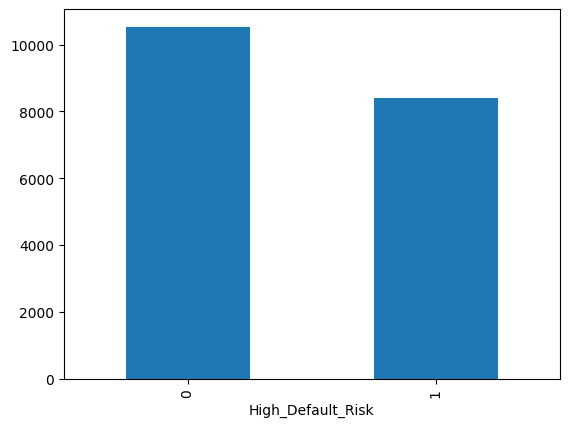

In [17]:
df['High_Default_Risk'].value_counts().plot(kind='bar')

 - we seee on target column using value counts soo we can understand that it is not an class imbalance problem

## univarite analysis

In [19]:
X=df.drop(['High_Default_Risk'],axis=1)
y=df['High_Default_Risk']

In [20]:
num_cols=X.select_dtypes(include='number').columns
cat_cols=X.select_dtypes(include='object').columns

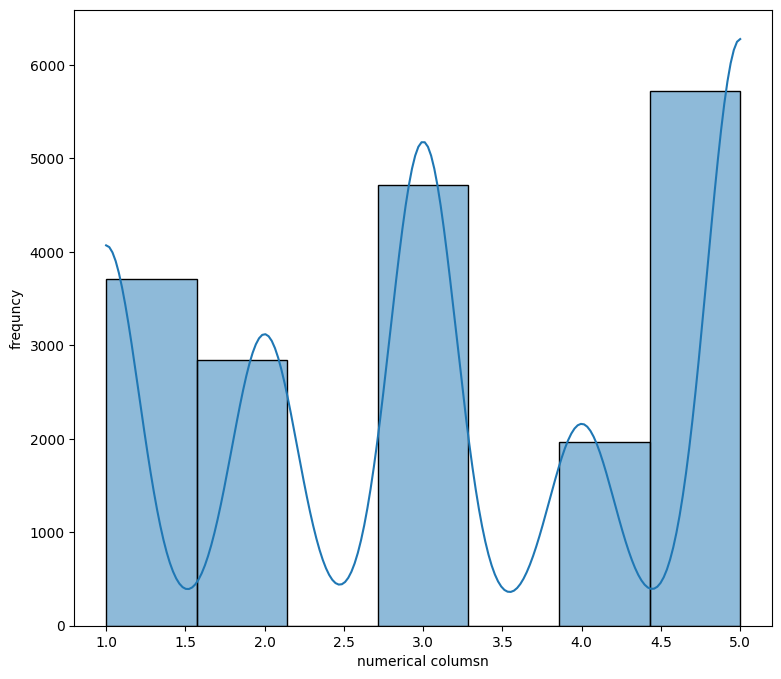

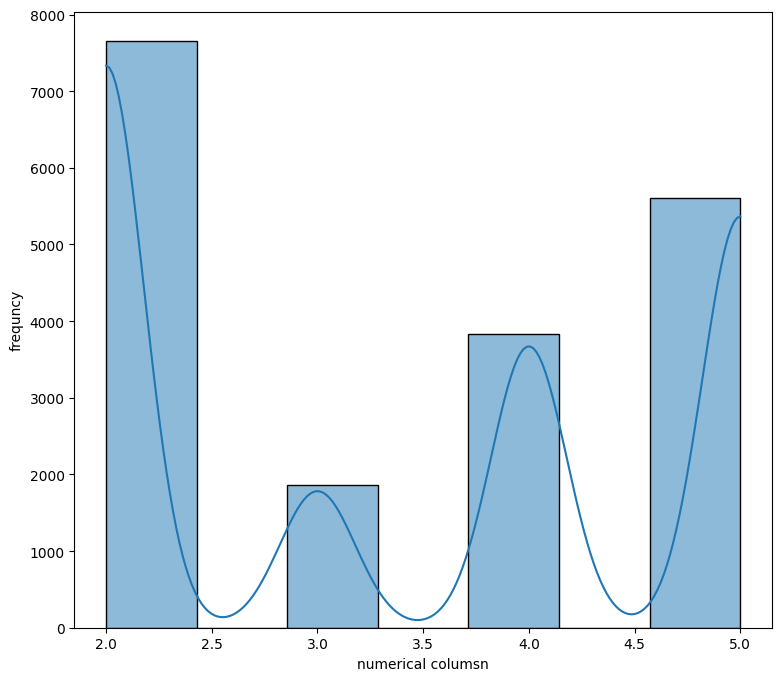

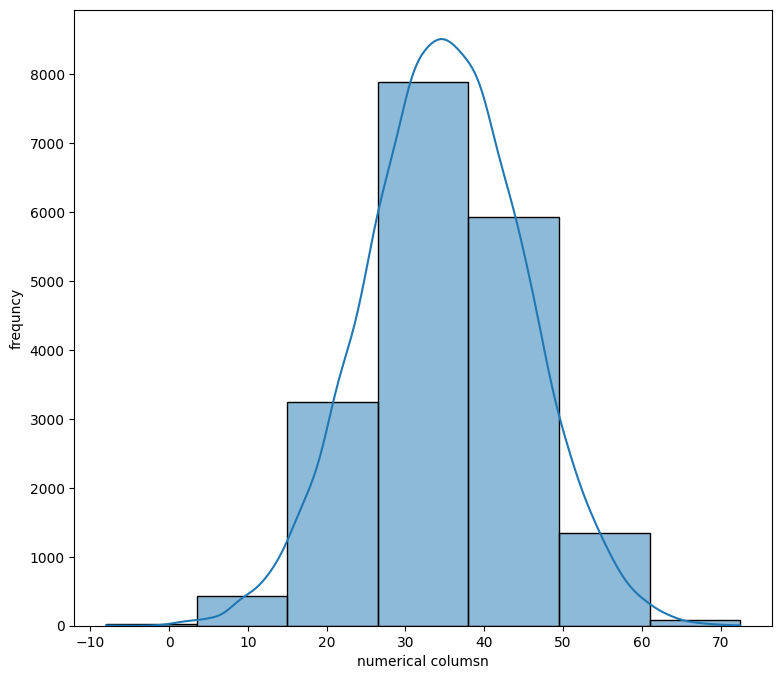

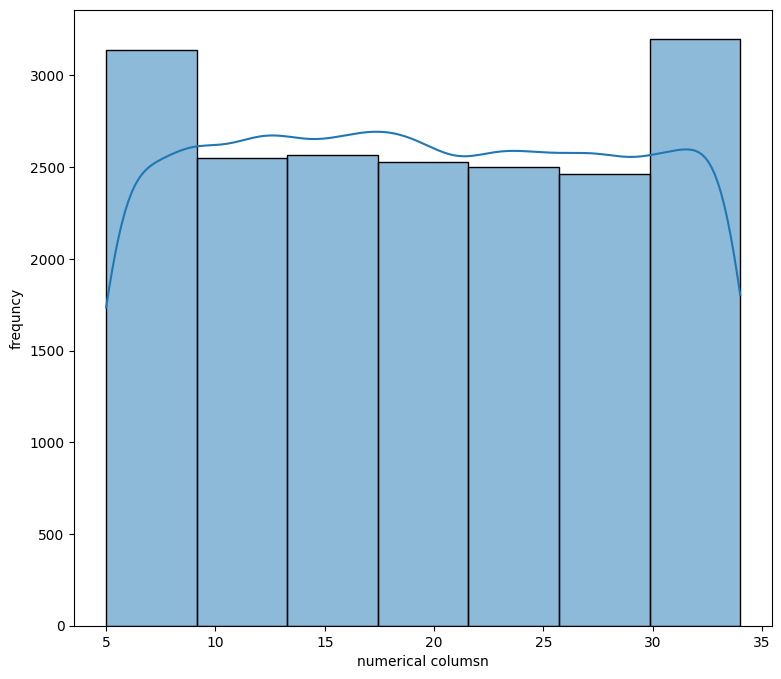

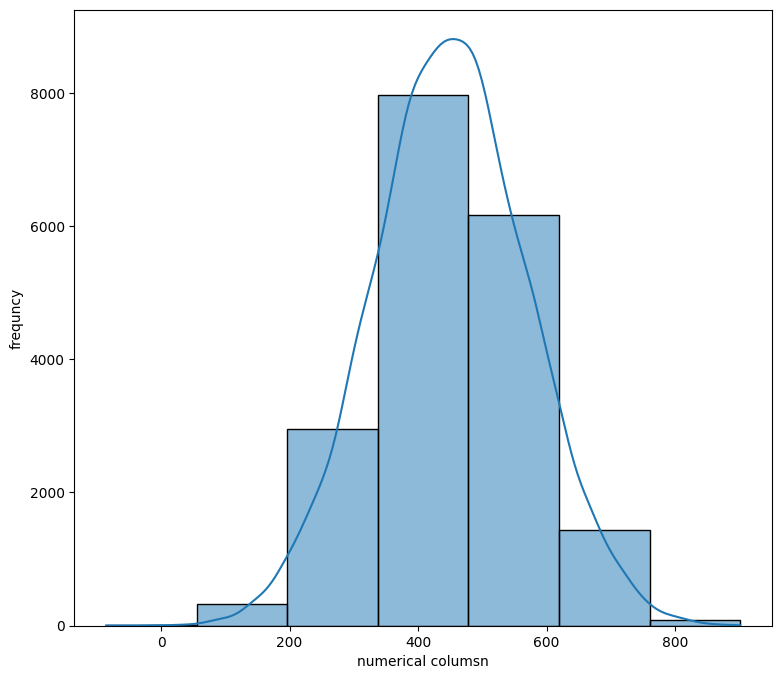

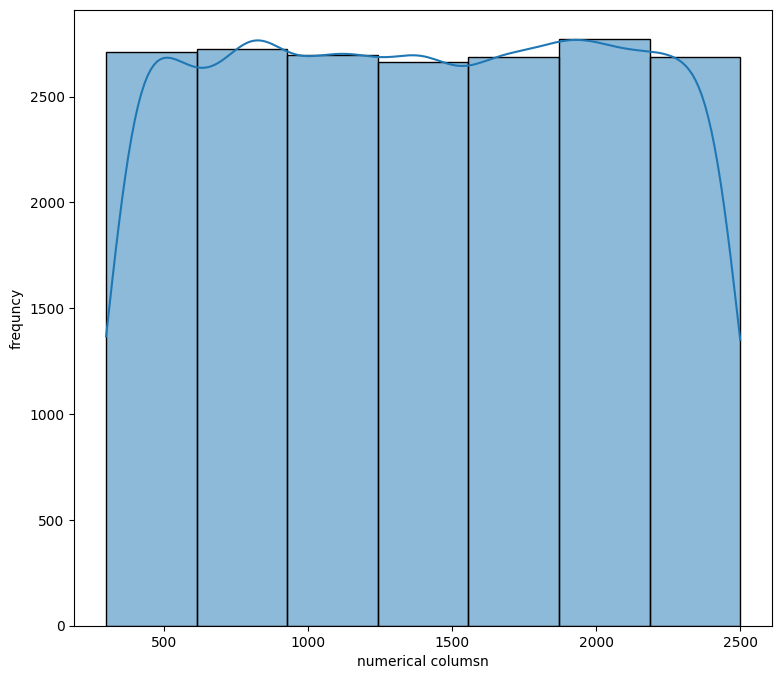

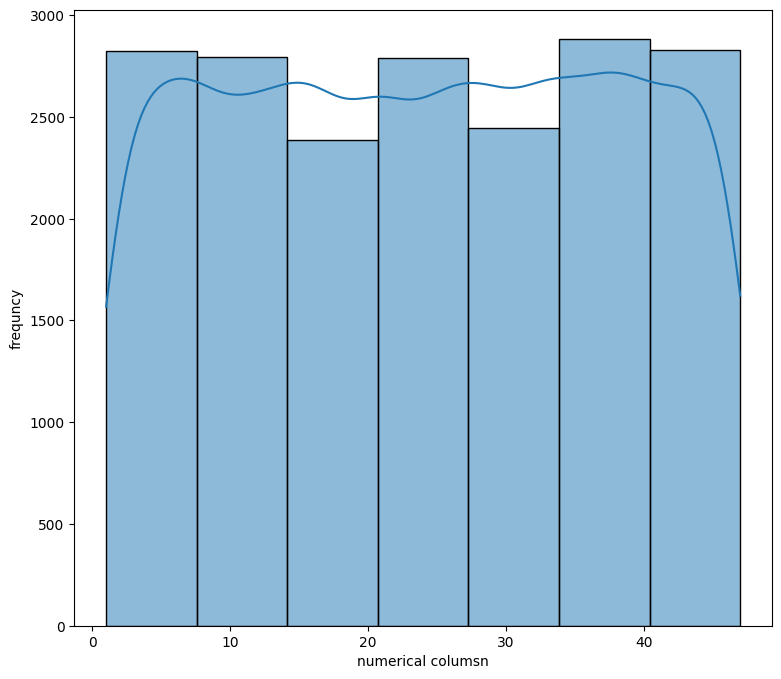

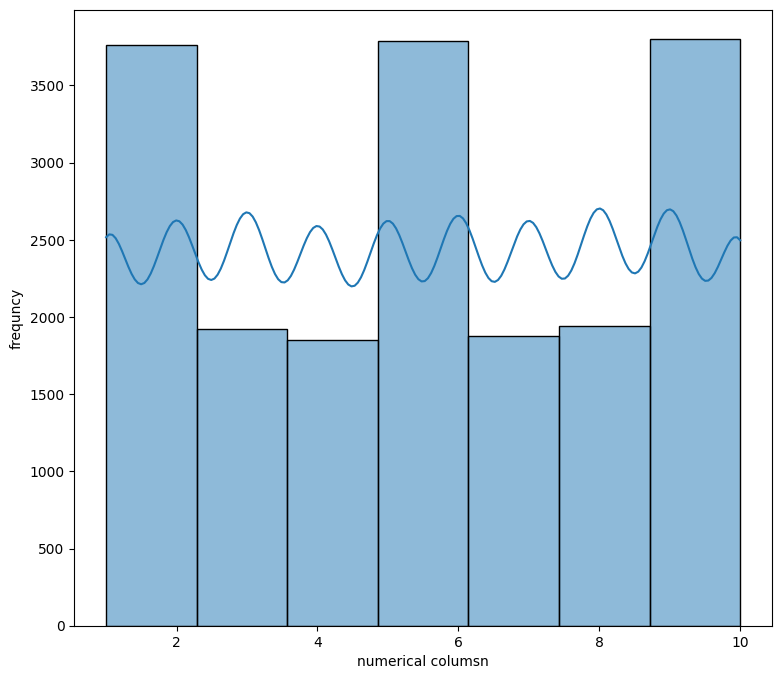

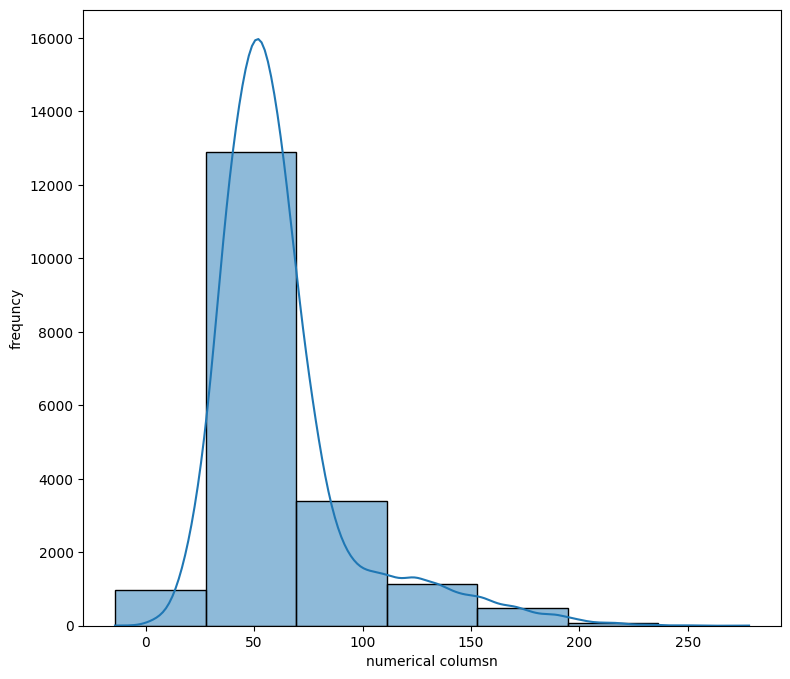

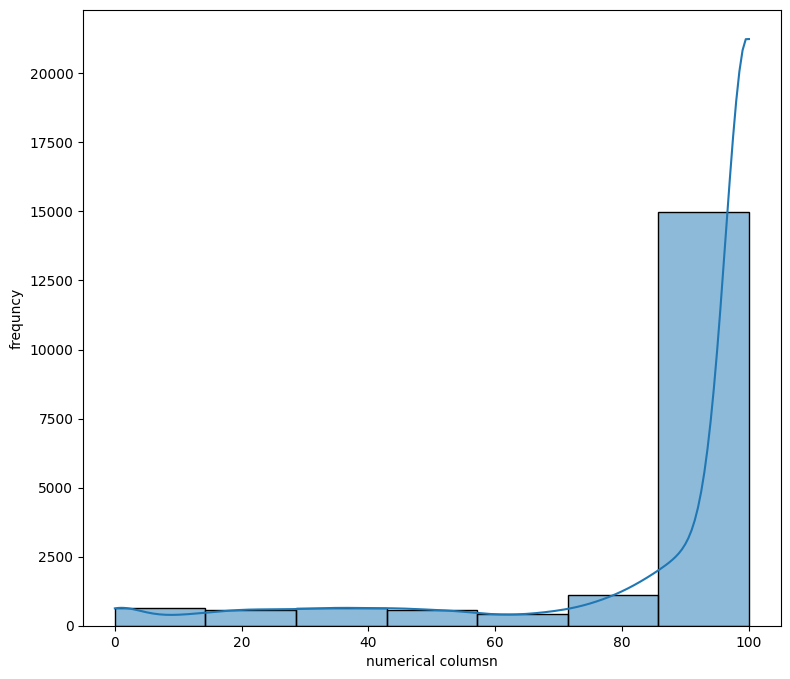

In [21]:
for i in num_cols:
    plt.figure(figsize=(9,8))
    sns.histplot(data=X,x=X[i],bins=7,kde=True)
    plt.xlabel("numerical columsn")
    plt.ylabel("frequncy")
    plt.show()

- after appying this histogram on this  numerica columns we understand that most of the colusmn are follwing normla distribution

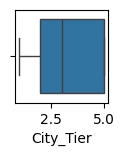

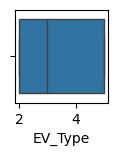

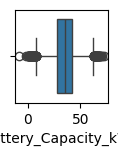

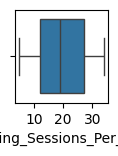

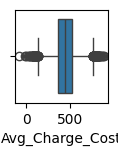

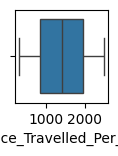

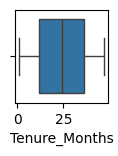

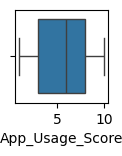

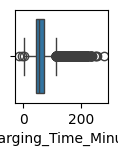

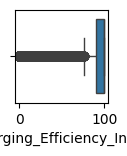

In [22]:
for i, j in enumerate (num_cols):
    plt.figure(figsize=(7,7))
    plt.subplot(5,5,i+1)
    sns.boxplot(data=X,x=X[j])
    plt.show()

- After applyinh  Box plot we understnd that most of columns are not having outliers  we are just detecting it but  we are not handing it coz it  we need to conider the   domain knowldge persion in orde to do handling outilers but am writing code for how to handle 

In [ ]:
def outiers(X,col):
    Q1=X[col].quantile(0.25)
    Q3=X[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    X[col]=X[col].clip(lower,upper)


    for col in num_cols:
        outliers(X,col)

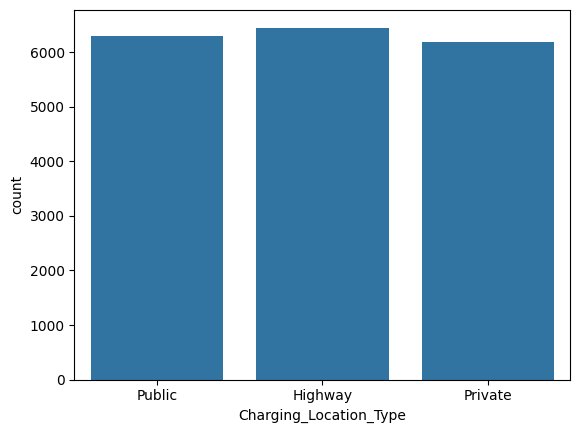

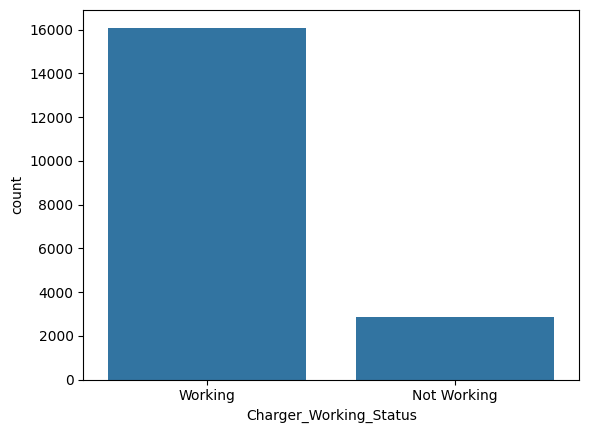

In [97]:
for   i in cat_cols:
    sns.countplot(data=X,x=X[i])
    plt.show()

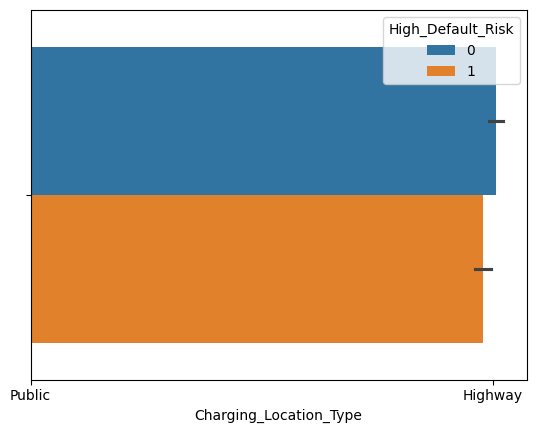

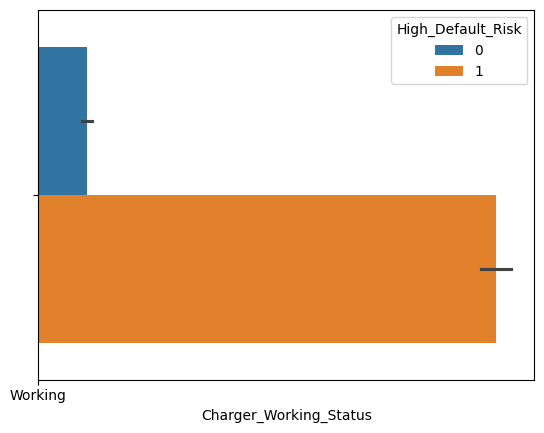

In [101]:
for i in cat_cols:
    sns.barplot(data=df,x=X[i],hue=y)
    plt.show()

# Model Building ( Handling Missing vaues, Scaling and  Encoding)

- in this part after visulizing teh data  we are now handling missing vaue for numerical columns we are  imputing with medain  and  for categorical  columns we are handling with mode

- for saling and  encoding for numerical columns we are doing standard scaling  which means  all values will come b/w -3 to +3 and  for encoding we are doing onehot encoding

In [23]:
########
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [24]:
X_train.shape,X_test.shape

((15156, 12), (3790, 12))

In [25]:
y_train.shape,y_test.shape

((15156,), (3790,))

In [26]:
num_cols

Index(['City_Tier', 'EV_Type', 'Battery_Capacity_kWh',
       'Charging_Sessions_Per_Month', 'Avg_Charge_Cost',
       'Distance_Travelled_Per_Month', 'Tenure_Months', 'App_Usage_Score',
       'Charging_Time_Minutes', 'Charging_Efficiency_Index'],
      dtype='object')

In [27]:
cat_cols

Index(['Charging_Location_Type', 'Charger_Working_Status'], dtype='object')

In [28]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
num_pipeline=Pipeline([
    ('imputaion',SimpleImputer(strategy='median')),
    ('scaling',StandardScaler())
    ])

In [29]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  OneHotEncoder
from sklearn.pipeline import Pipeline
cat_pipeline=Pipeline([
    ('imputaion',SimpleImputer(strategy='most_frequent')),
    ('encoding',OneHotEncoder(handle_unknown='ignore',drop='first'))
    ])

In [30]:
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer([
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
        ],remainder='drop')

In [31]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [32]:
X_train_p=preprocessor.fit_transform(X_train,y_train)

In [35]:
X_train_p.shape

(15156, 13)

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,precision_score,recall_score

In [41]:
models={
    "LogisticRegression":LogisticRegression(),
    "DecisionTree":DecisionTreeClassifier(),
    "RandomForest":RandomForestClassifier(),
    "AdaboostClassifier":AdaBoostClassifier(),
    "GradinetBoosting":GradientBoostingClassifier(),
    "XGB":XGBClassifier()
}
    

In [48]:
from sklearn.feature_selection  import SelectKBest,f_classif
for  name,model in models.items():
    pipe=Pipeline([
        ('preprocessing',preprocessor),
        ('features',SelectKBest(score_func=f_classif,k=12)),
        ('model',model)
    ])



    pipe.fit(X_train,y_train)


    y_train_pred=pipe.predict(X_train)
    y_test_pred=pipe.predict(X_test)


    print(name)
    print("metrics on training ")
    print(f"accuracy {accuracy_score(y_train,y_train_pred)}")
    print(f"f1score {f1_score(y_train,y_train_pred)}")
    print(f"precision {precision_score(y_train,y_train_pred)}")
    print(f"reacll {recall_score(y_train,y_train_pred)}")
    print(f"confusion matrix {confusion_matrix(y_train,y_train_pred)}")
    print("*****************************")

    

    print("**************************")
    print(name)
    print("metrics on testing ")
    print(f"accuracy {accuracy_score(y_test,y_test_pred)}")
    print(f"f1score {f1_score(y_test,y_test_pred)}")
    print(f"precision {precision_score(y_test,y_test_pred)}")
    print(f"reacll {recall_score(y_test,y_test_pred)}")
    print(f"confusion matrix {confusion_matrix(y_test,y_test_pred)}")

    

     

    

LogisticRegression
metrics on training 
accuracy 0.7500659804697809
f1score 0.6993650793650794
precision 0.7499574468085106
reacll 0.6551672862453531
confusion matrix [[6962 1469]
 [2319 4406]]
*****************************
**************************
LogisticRegression
metrics on testing 
accuracy 0.750131926121372
f1score 0.6998415213946118
precision 0.7520435967302452
reacll 0.6544161232957914
confusion matrix [[1739  364]
 [ 583 1104]]
DecisionTree
metrics on training 
accuracy 1.0
f1score 1.0
precision 1.0
reacll 1.0
confusion matrix [[8431    0]
 [   0 6725]]
*****************************
**************************
DecisionTree
metrics on testing 
accuracy 0.691820580474934
f1score 0.6588785046728972
precision 0.6493955094991365
reacll 0.6686425607587433
confusion matrix [[1494  609]
 [ 559 1128]]
RandomForest
metrics on training 
accuracy 1.0
f1score 1.0
precision 1.0
reacll 1.0
confusion matrix [[8431    0]
 [   0 6725]]
*****************************
**************************
R

## AdaBoost got selected
- adaboost classfier got selected coz it has  accuracy of 78% on both training and testing soo we are doing hyper parameter on this model only

- we are uinsg RandomizedSearch here and cv=3

In [52]:
params={
    'n_iterations':[200,100,300],
    'max_depth':[20,5,10],
    'learning_rate':[0.2,0.5,0.7],
    'min_sample_leaf':[1,2,5]

}

In [53]:
adaboost=[
    ('Adaboost',AdaBoostClassifier(),params)
]

In [69]:
from sklearn.model_selection import RandomizedSearchCV
best={}
for  name,model,params in adaboost:
    pipe=Pipeline([
        ('preprocessor',preprocessor),
        ('model',model)
    ])


    pipe.fit(X_train,y_train)


    ada=RandomizedSearchCV(
        estimator=pipe,
        param_distributions=params,
        n_iter=30,
        cv=3,
        n_jobs=-1,
        random_state=42
    )

    ada.fit(X_train,y_train)

    best[name]=ada.best_estimator_
    print(ada.best_estimator_)

    
    

ValueError: Invalid parameter 'n_iterations' for estimator Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputaion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  Index(['City_Tier', 'EV_Type', 'Battery_Capacity_kWh',
       'Charging_Sessions_Per_Month', 'Avg_Charge_Cost',
       'Distance_Travelled_Per_Month', 'Tenure_Months', 'App_Usage_Score',
       'Charging_Time_Minutes', 'Charging_Efficiency_Index'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputaion',
                                           

In [84]:
best_model={
    "AdaboostClassifier":AdaBoostClassifier(learning_rate=0.2)
            }

In [88]:
from sklearn.feature_selection  import SelectKBest,f_classif
for  name,model in best_model.items():
    pipe=Pipeline([
        ('preprocessing',preprocessor),
        ('features',SelectKBest(score_func=f_classif,k=12)),
        ('model',model)
    ])



    pipe.fit(X_train,y_train)


    y_train_pred=pipe.predict(X_train)
    y_test_pred=pipe.predict(X_test)


    print(name)
    print("metrics on training ")
    print(f"accuracy {accuracy_score(y_train,y_train_pred)}")
    print(f"f1score {f1_score(y_train,y_train_pred)}")
    print(f"precision {precision_score(y_train,y_train_pred)}")
    print(f"reacll {recall_score(y_train,y_train_pred)}")
    print(f"confusion matrix {confusion_matrix(y_train,y_train_pred)}")
    print("*****************************")

    

    print("**************************")
    print(name)
    print("metrics on testing ")
    print(f"accuracy {accuracy_score(y_test,y_test_pred)}")
    print(f"f1score {f1_score(y_test,y_test_pred)}")
    print(f"precision {precision_score(y_test,y_test_pred)}")
    print(f"reacll {recall_score(y_test,y_test_pred)}")
    print(f"confusion matrix {confusion_matrix(y_test,y_test_pred)}")

    

     

    

AdaboostClassifier
metrics on training 
accuracy 0.7781736605964634
f1score 0.7030559971736442
precision 0.8657820317598434
reacll 0.59182156133829
confusion matrix [[7814  617]
 [2745 3980]]
*****************************
**************************
AdaboostClassifier
metrics on testing 
accuracy 0.7823218997361477
f1score 0.7116392869626005
precision 0.8671209540034072
reacll 0.6034380557202134
confusion matrix [[1947  156]
 [ 669 1018]]


In [102]:
import pickle
with open("model.pkl","wb")as file:
  pickle.dump(pipe,file)

print(" sucessfully dumped pkl ")


 sucessfully dumped pkl 
